# Unit-testing some modules / functions to ensure accuracy of implementation

## Test 1: Fitting baseline hazard function

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from raas.degradation_learner import DegradationLearner

In [2]:
def generate_degradation_data(n_failures_target, d, theta_true, Lambda_0, Lambda_0_inv,
                              rental_scale=10.0, max_rentals_per_life=200, seed=42):
    """
    Simulates the RaaS machine degradation process, producing data in the
    same start-stop format as simulation.py's degradation_history.

    One machine operates at a time. Customers arrive sequentially, each with
    a random context x_i and rental duration T_i. During rental i the hazard is:

        lambda(t) = lambda_0(t_age + t) * exp(theta^T (X + x_i))

    where X = accumulated context from prior survivals, t_age = cumulative
    active time, and t in [0, T_i] is the time into the current rental.

    On failure the machine resets (X=0, t_age=0) and a new life begins.
    On survival, X and t_age accumulate.

    Returns a DataFrame with columns: start, stop, event, X0, ..., X{d-1}
    matching the format appended to self.degradation_history in Simulator.run().
    """
    rng = np.random.RandomState(seed)
    records = []
    n_failures = 0

    while n_failures < n_failures_target:
        # --- Fresh machine (new life) ---
        accumulated_context = np.zeros(d)
        t_age = 0.0

        for _ in range(max_rentals_per_life):
            # Sample customer context from positive orthant of unit ball
            while True:
                x_i = np.abs(rng.uniform(-1, 1, d))
                if np.linalg.norm(x_i) <= 1:
                    break
            T_i = rng.exponential(rental_scale)

            X_total = accumulated_context + x_i
            exp_term = np.exp(np.dot(theta_true, X_total))

            # Cumulative hazard over the rental: exp(theta^T X_total) * [Lambda_0(t_age+T) - Lambda_0(t_age)]
            H = exp_term * (Lambda_0(t_age + T_i) - Lambda_0(t_age))

            # Draw exponential clock
            E = rng.exponential(1.0)

            if E >= H:
                # --- Survived this rental ---
                records.append({
                    'start': t_age,
                    'stop': t_age + T_i,
                    'event': 0,
                    **{f'X{j}': X_total[j] for j in range(d)}
                })
                accumulated_context = X_total
                t_age += T_i
            else:
                # --- Failed during this rental ---
                # Solve for failure time f:
                #   exp_term * [Lambda_0(t_age + f) - Lambda_0(t_age)] = E
                #   Lambda_0(t_age + f) = Lambda_0(t_age) + E / exp_term
                #   f = Lambda_0_inv(Lambda_0(t_age) + E / exp_term) - t_age
                target_Lambda = Lambda_0(t_age) + E / exp_term
                f = Lambda_0_inv(target_Lambda) - t_age
                f = np.clip(f, 1e-6, T_i)

                records.append({
                    'start': t_age,
                    'stop': t_age + f,
                    'event': 1,
                    **{f'X{j}': X_total[j] for j in range(d)}
                })
                n_failures += 1
                break  # Machine resets → new life

    return pd.DataFrame(records)

In [3]:
def test_exponential_baseline():
    """
    Test 1: Constant (exponential) baseline hazard.

    Ground truth:
        lambda_0(t) = lam             (constant)
        Lambda_0(t) = lam * t         (linear)

    Machine goes through multiple rentals per life. Covariates accumulate.
    With constant baseline, the Breslow+KDE pipeline should recover a
    linear cumulative hazard with the correct slope.
    """
    d = 2
    theta_true = np.array([0.5, 0.3])
    lam = 0.005

    Lambda_0      = lambda t: lam * t
    Lambda_0_inv  = lambda y: y / lam

    data = generate_degradation_data(
        n_failures_target=1000, d=d, theta_true=theta_true,
        Lambda_0=Lambda_0, Lambda_0_inv=Lambda_0_inv,
        rental_scale=10.0, seed=42
    )
    n_events  = data['event'].sum()
    n_records = len(data)
    n_lives   = n_events  # each life ends with exactly 1 failure
    avg_rentals_per_life = n_records / n_lives
    print(f"Records: {n_records}, Failures: {n_events}, "
          f"Avg rentals/life: {avg_rentals_per_life:.1f}")

    learner = DegradationLearner(d=d)
    learner.fit(data)

    theta_hat = learner.get_theta()
    theta_err = np.linalg.norm(theta_hat - theta_true)
    print(f"theta_true = {theta_true}")
    print(f"theta_hat  = {np.round(theta_hat, 4)}")
    print(f"theta L2 error = {theta_err:.4f}")
    # print(f"hazard_scale   = {learner.hazard_scale:.6f}")

    # Evaluate cumulative baseline on a grid within observed data range
    max_stop = data['stop'].max()
    test_t = np.linspace(1, max_stop * 0.8, 80)
    true_vals = np.array([Lambda_0(ti) for ti in test_t])
    est_vals  = learner.cum_baseline(test_t)

    rel_err = np.abs(est_vals - true_vals) / (true_vals + 1e-12)
    mean_rel = np.mean(rel_err)
    max_rel  = np.max(rel_err)
    print(f"\nCumulative baseline Lambda_0(t):")
    print(f"  Mean relative error: {mean_rel:.4f}")
    print(f"  Max  relative error: {max_rel:.4f}")

    # --- Plot ---
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    axes[0].plot(test_t, true_vals, 'b-',  lw=2, label=rf'True $\Lambda_0(t) = {lam}t$')
    axes[0].plot(test_t, est_vals,  'r--', lw=2, label=r'Estimated $\hat\Lambda_0(t)$')
    axes[0].set_xlabel('Cumulative Active Time')
    axes[0].set_ylabel(r'$\Lambda_0(t)$')
    axes[0].set_title('Exponential Baseline: Cumulative Hazard')
    axes[0].legend(); axes[0].grid(True)

    axes[1].plot(test_t, rel_err, 'g-', lw=2)
    axes[1].set_xlabel('Cumulative Active Time')
    axes[1].set_ylabel('Relative Error')
    axes[1].set_title(r'$|\hat\Lambda_0 - \Lambda_0| \,/\, \Lambda_0$')
    axes[1].grid(True)
    plt.tight_layout(); plt.show()

    # --- Assertions ---
    assert theta_err < 0.15, f"Theta error too large: {theta_err:.4f}"
    assert mean_rel  < 0.30, f"Mean baseline relative error too large: {mean_rel:.4f}"
    print("\nExponential baseline test PASSED.")

In [4]:
def test_weibull_baseline():
    """
    Test 2: Weibull (increasing) baseline hazard.

    Ground truth:
        lambda_0(t)    = alpha * beta * t^(beta-1)    (increasing)
        Lambda_0(t)    = alpha * t^beta
        Lambda_0^-1(y) = (y / alpha)^(1/beta)

    With alpha=0.00005, beta=2:
        lambda_0(t) = 0.0001 t       (linearly increasing hazard rate)
        Lambda_0(t) = 0.00005 t^2    (quadratic cumulative hazard)

    Tests that the KDE smoothing recovers a non-constant shape with
    correct magnitude, using multi-rental machine lives.
    """
    d = 2
    theta_true = np.array([0.5, 0.3])
    alpha, beta = 0.00005, 2.0

    Lambda_0      = lambda t: alpha * t**beta
    Lambda_0_inv  = lambda y: (y / alpha)**(1.0 / beta)

    data = generate_degradation_data(
        n_failures_target=1000, d=d, theta_true=theta_true,
        Lambda_0=Lambda_0, Lambda_0_inv=Lambda_0_inv,
        rental_scale=10.0, seed=42
    )
    n_events  = data['event'].sum()
    n_records = len(data)
    n_lives   = n_events
    avg_rentals_per_life = n_records / n_lives
    print(f"Records: {n_records}, Failures: {n_events}, "
          f"Avg rentals/life: {avg_rentals_per_life:.1f}")

    learner = DegradationLearner(d=d)
    learner.fit(data)

    theta_hat = learner.get_theta()
    theta_err = np.linalg.norm(theta_hat - theta_true)
    print(f"theta_true = {theta_true}")
    print(f"theta_hat  = {np.round(theta_hat, 4)}")
    print(f"theta L2 error = {theta_err:.4f}")
    # print(f"hazard_scale   = {learner.hazard_scale:.6f}")

    # Evaluate cumulative baseline within the observed data range
    max_stop = data['stop'].max()
    test_t = np.linspace(5, max_stop * 0.8, 80)
    true_vals = np.array([Lambda_0(ti) for ti in test_t])
    est_vals  = learner.cum_baseline(test_t)

    rel_err = np.abs(est_vals - true_vals) / (true_vals + 1e-12)
    mean_rel = np.mean(rel_err)
    max_rel  = np.max(rel_err)
    print(f"\nCumulative baseline Lambda_0(t):")
    print(f"  Mean relative error: {mean_rel:.4f}")
    print(f"  Max  relative error: {max_rel:.4f}")

    # --- Plot ---
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    axes[0].plot(test_t, true_vals, 'b-',  lw=2,
                 label=rf'True $\Lambda_0(t) = {alpha}\,t^{{{beta:.0f}}}$')
    axes[0].plot(test_t, est_vals,  'r--', lw=2,
                 label=r'Estimated $\hat\Lambda_0(t)$')
    axes[0].set_xlabel('Cumulative Active Time')
    axes[0].set_ylabel(r'$\Lambda_0(t)$')
    axes[0].set_title('Weibull Baseline: Cumulative Hazard')
    axes[0].legend(); axes[0].grid(True)

    axes[1].plot(test_t, rel_err, 'g-', lw=2)
    axes[1].set_xlabel('Cumulative Active Time')
    axes[1].set_ylabel('Relative Error')
    axes[1].set_title(r'$|\hat\Lambda_0 - \Lambda_0| \,/\, \Lambda_0$')
    axes[1].grid(True)
    plt.tight_layout(); plt.show()

    # --- Assertions ---
    assert theta_err < 0.15, f"Theta error too large: {theta_err:.4f}"
    assert mean_rel  < 0.40, f"Mean baseline relative error too large: {mean_rel:.4f}"
    print("\nWeibull baseline test PASSED.")

TEST 1: Exponential (constant) baseline hazard
Records: 5350, Failures: 1000, Avg rentals/life: 5.3
RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            2     M =           10

At X0         2 variables are exactly at the bounds

At iterate    0    f=  5.91213D+03    |proj g|=  1.00000D+00

At iterate    1    f=  5.73319D+03    |proj g|=  6.46350D-01

At iterate    2    f=  5.73195D+03    |proj g|=  6.04397D-01

At iterate    3    f=  5.73161D+03    |proj g|=  3.84031D-01

At iterate    4    f=  5.73154D+03    |proj g|=  3.53753D-02

At iterate    5    f=  5.73154D+03    |proj g|=  9.51569D-04

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *


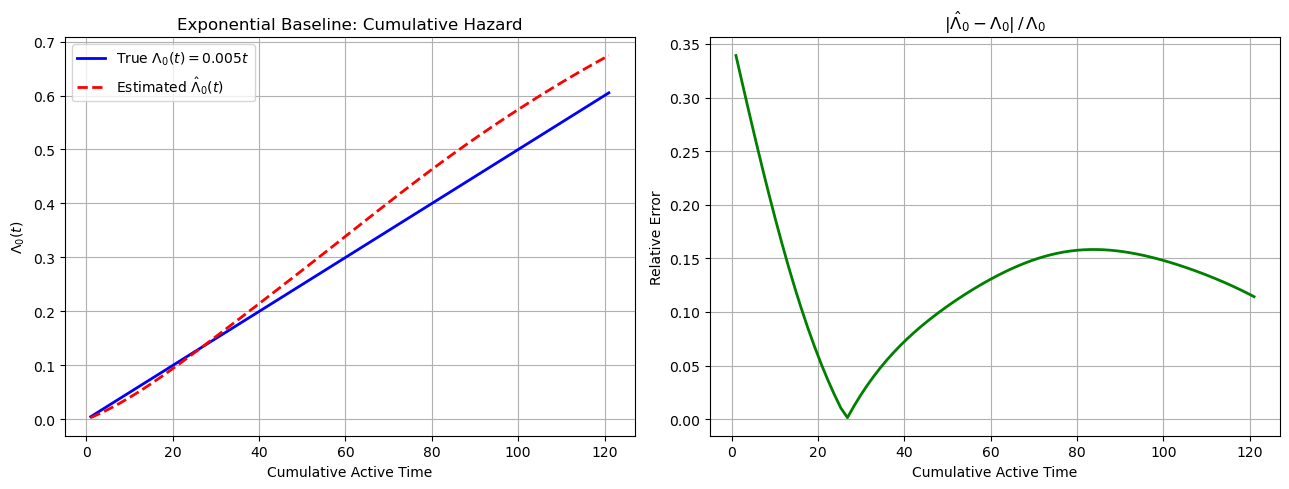


Exponential baseline test PASSED.

TEST 2: Weibull (increasing) baseline hazard
Records: 6230, Failures: 1000, Avg rentals/life: 6.2
RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            2     M =           10

At X0         2 variables are exactly at the bounds

At iterate    0    f=  5.91213D+03    |proj g|=  1.00000D+00

At iterate    1    f=  5.67997D+03    |proj g|=  6.22466D-01

At iterate    2    f=  5.67906D+03    |proj g|=  5.92546D-01

At iterate    3    f=  5.67863D+03    |proj g|=  4.32754D-01

At iterate    4    f=  5.67860D+03    |proj g|=  3.25831D-02

At iterate    5    f=  5.67860D+03    |proj g|=  1.69202D-03

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final

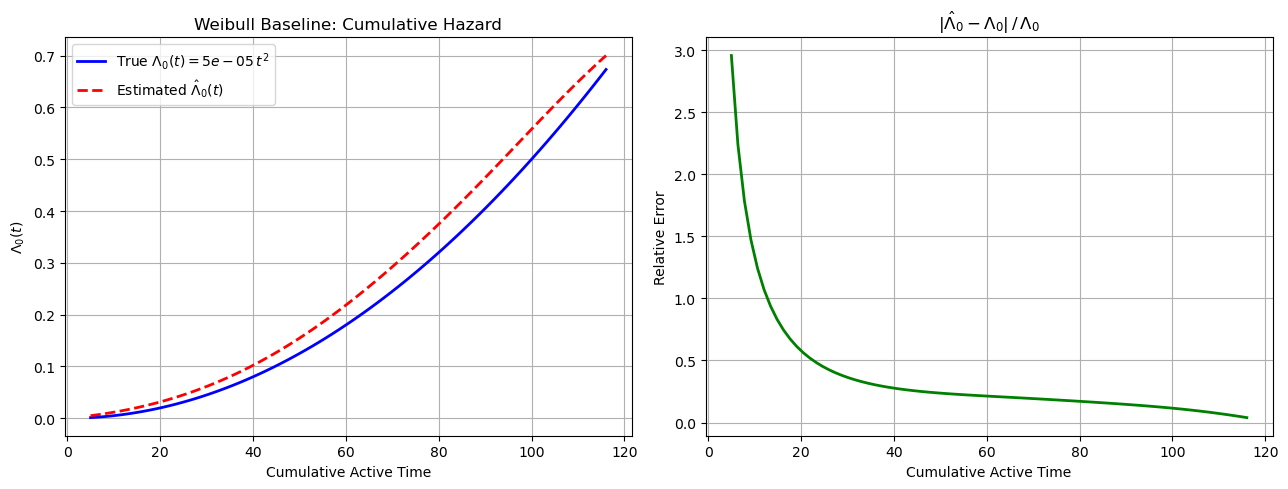


Weibull baseline test PASSED.


In [6]:
print("=" * 60)
print("TEST 1: Exponential (constant) baseline hazard")
print("=" * 60)
test_exponential_baseline()

print("\n" + "=" * 60)
print("TEST 2: Weibull (increasing) baseline hazard")
print("=" * 60)
test_weibull_baseline()